In [1]:
# -------------------------------
# 1. Imports & Path Setup
# -------------------------------
import os
import sys
import pandas as pd
import numpy as np

# Add project root to sys.path
notebook_dir = os.getcwd() 
project_root = os.path.abspath(os.path.join(notebook_dir, "..")) 
if project_root not in sys.path:
    sys.path.append(project_root)

from src.config import Config as cfg
from src.data_loader import load_data, prepare_data




import h2o
from h2o.automl import H2OAutoML
from h2o.estimators.stackedensemble import H2OStackedEnsembleEstimator
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import time

# -------------------------------
# 2. Load & Prepare Data
# -------------------------------
# Using your modular data loader to get the specific training/test sets
X_train, X_test, y_train, y_test = load_data("encoded")
X_train, X_test, y_train_numeric, y_test_numeric, test_ids, num_classes, int_to_label = prepare_data(
    X_train, X_test, y_train, y_test, target=cfg.TARGET, drop_id=True
)






Number of classes: 2
X_train shape: (300000, 116)
X_test shape: (200000, 116)
y_train shape: (300000,)
y_test labels are not available


In [2]:

from sklearn.model_selection import train_test_split


X_train, _, y_train_numeric, _ = train_test_split(
    X_train,
    y_train_numeric,
    test_size=0.95,              # keep only 10%
    random_state=42,
    stratify=y_train_numeric    # IMPORTANT: preserves class balance
)

print("Original:", X_train.shape)
print("Sample:", X_train.shape)

X_test = X_test.sample(
    frac=0.07,
    random_state=42
)

Original: (15000, 116)
Sample: (15000, 116)


In [3]:
from src.data_splitter import DataSplitter

# ⚠️ If you don’t set folds_path, it will generate new random splits every time you call split().
splitter = DataSplitter(
    method="stratified_kfold",
    n_splits=5,
    random_state=42,
    # random_states=[42, 1337],  # multi-seed CV
    folds_path="data/folds.npy" # folds_xgb.npy?
)

folds = list(splitter.split(X_train, y_train_numeric, reuse_folds=True, verbose=True))


✅ Loaded 5 folds from data/folds.npy
♻️ Reusing existing folds
--- Splitting data ---
Method: stratified_kfold
Number of splits: 5
Random seeds: [42]
Dataset size: 15000
Total folds: 5

Fold 0: Train size=12000, Val size=3000
Fold 1: Train size=12000, Val size=3000
Fold 2: Train size=12000, Val size=3000
Fold 3: Train size=12000, Val size=3000
Fold 4: Train size=12000, Val size=3000


In [12]:
# ---------------------------------------------------------
# H2O AutoML: THE STABLE RECOVERY PIPELINE
# ---------------------------------------------------------
import h2o
from h2o.automl import H2OAutoML
import pandas as pd

# 1. KILL AND RESTART (The only way to clear the 'Connection Refused' error)
try:
    h2o.shutdown(prompt=False)
except:
    pass

h2o.init(max_mem_size="8G", nthreads=-1)

# 2. DATA SANITIZATION
# We create a clean DF without the custom fold_id to test stability first
train_df = X_train.copy().reset_index(drop=True)
train_df[cfg.TARGET] = y_train_numeric

# Drop any columns that are objects/strings (H2O prefers factors or numeric)
# Also drop columns with zero variance
for col in train_df.columns:
    if train_df[col].dtype == 'object':
        train_df[col] = train_df[col].astype('category')

train_hf = h2o.H2OFrame(train_df)
test_hf = h2o.H2OFrame(X_test.reset_index(drop=True))

target = cfg.TARGET
train_hf[target] = train_hf[target].asfactor()

# 3. THE "STABILITY TEST" RUN
# We use nfolds=5 (internal H2O CV) instead of your custom folds.
# This tells us if the issue is the DATA or the FOLD MAPPING.
aml = H2OAutoML(
    max_models=10,                  # Small run to check stability
    seed=cfg.RANDOM_STATE,
    nfolds=5,                       # Use H2O's internal stratified splitter
    exclude_algos=["DeepLearning", "XGBoost"], # XGBoost can crash on some CPUs
    balance_classes=True,
    project_name="stability_test"
)

print("🚀 Testing Data Stability with internal CV...")
aml.train(y=target, training_frame=train_hf)

# 4. RESULTS
if aml.leaderboard.nrows > 0:
    print("✅ Success! The data is fine. The issue was the custom fold indices.")
    print(aml.leaderboard.head())
    
    # 5. GENERATE SUBMISSION
    preds = aml.leader.predict(test_hf)
    y_test_proba = h2o.as_list(preds)["p1"].values
    submission = pd.DataFrame({cfg.ID: test_ids, cfg.TARGET: y_test_proba})
    submission.to_csv(cfg.SUB_PATH, index=False)
else:
    print("❌ Even internal CV failed. Check your target column for NaNs or Infinity.")

Checking whether there is an H2O instance running at http://localhost:54321.

/tmp/ipykernel_429213/1173335904.py:10: H2ODeprecationWarning: Deprecated, use ``h2o.cluster().shutdown()``.
  h2o.shutdown(prompt=False)


.... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "26.0.2" 2026-03-17; OpenJDK Runtime Environment (build 26.0.2); OpenJDK 64-Bit Server VM (build 26.0.2, mixed mode, sharing)
  Starting server from /home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmppqhsc1cs
  JVM stdout: /tmp/tmppqhsc1cs/h2o_ismail_started_from_python.out
  JVM stderr: /tmp/tmppqhsc1cs/h2o_ismail_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Africa/Algiers
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,4 months and 29 days
H2O_cluster_name:,H2O_from_python_ismail_t7p5md
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.984 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
🚀 Testing Data Stability with internal CV...
AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%
✅ Success! The data is fine. The issue was the custom fold indices.
model_id                                                      auc    logloss     aucpr    mean_per_class_error      rmse       mse
StackedEnsemble_AllModels_1_AutoML_1_20260422_212425     0.786897   0.498317  0.617849                0.288095  0.406717  0.165418
StackedEnsemble_BestOfFamily_1_AutoML_1_20260422_212425  0.786327   0.498749  0.616907                0.287753  0.406936  0.165597
GLM_1_AutoML_1_20260422_212425                           0.781892   0.502785  0.60951                 0.290499  0.408745  0.167073
GBM_1_AutoML_1_20260422_212425                           0.772251   0.514692  

/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


# Internal CV

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "26.0.2" 2026-03-17; OpenJDK Runtime Environment (build 26.0.2); OpenJDK 64-Bit Server VM (build 26.0.2, mixed mode, sharing)
  Starting server from /home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmplr636xmm
  JVM stdout: /tmp/tmplr636xmm/h2o_ismail_started_from_python.out
  JVM stderr: /tmp/tmplr636xmm/h2o_ismail_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Africa/Algiers
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,4 months and 29 days
H2O_cluster_name:,H2O_from_python_ismail_y9qv5e
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.984 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Features: ['bin_0', 'bin_1', 'bin_2', 'bin_3', 'bin_4', 'ord_0', 'ord_1', 'ord_2', 'ord_3', 'ord_4', 'day', 'month', 'nom_0_Green', 'nom_0_Red', 'nom_1_Polygon', 'nom_1_Square', 'nom_1_Star', 'nom_1_Trapezoid', 'nom_1_Triangle', 'nom_2_Cat', 'nom_2_Dog', 'nom_2_Hamster', 'nom_2_Lion', 'nom_2_Snake', 'nom_3_China', 'nom_3_Costa Rica', 'nom_3_Finland', 'nom_3_India', 'nom_3_Russia', 'nom_4_Oboe', 'nom_4_Piano', 'nom_4_Theremin', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'ord_5_oe_add', 'ord_5_oe_join', 'ord_5_oe1', 'ord_5_oe2', 'hash_nom_5', 'le_nom_5', 'le_nom_6', 'le_nom_7', 'le_nom_8', 'le_nom_9', 'nom_0_te', 'nom_0_cnt', 'nom_1_te', 'nom_1_cnt', 'nom_1_cluster', 'nom_2_woe', 'nom_2_cnt', 'nom_2_cluster', 'nom_3_te', 'nom_3_cnt', 'nom_3_cluster', 'nom_4_te', 'nom_4_cnt', 'nom_4_cluster', 'ord

/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


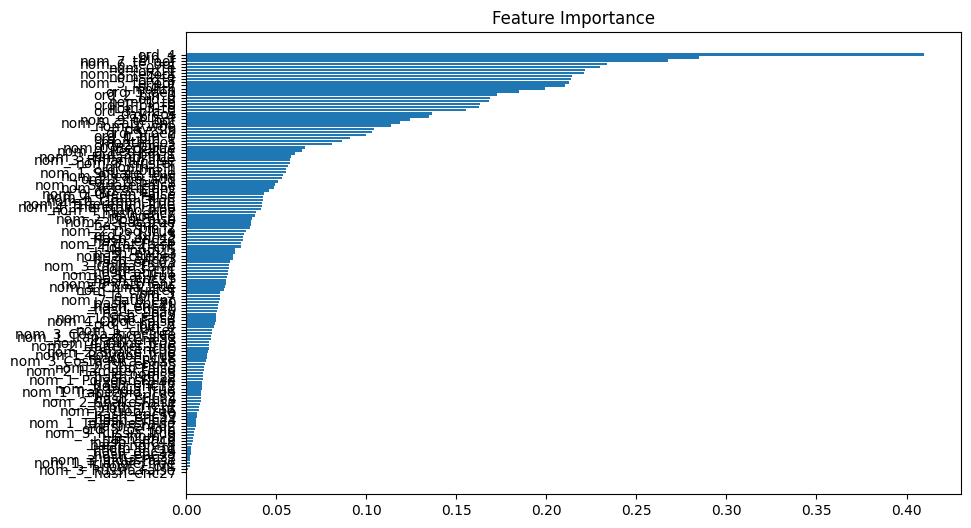

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%
Submission saved!


/home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


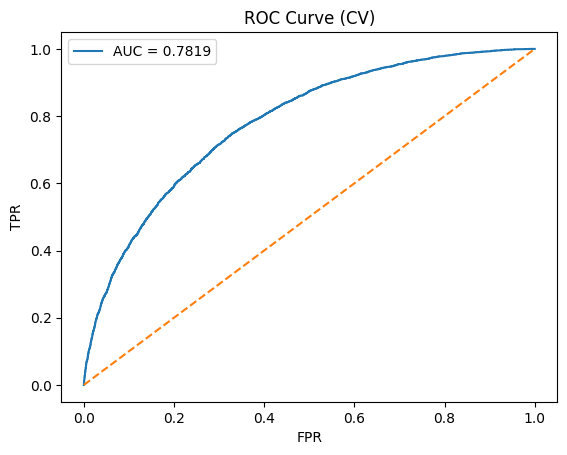

H2O session _sid_949c closed.


/tmp/ipykernel_397002/2994328572.py:147: H2ODeprecationWarning: Deprecated, use ``h2o.cluster().shutdown()``.
  h2o.shutdown(prompt=False)


In [3]:
# -------------------------------
# H2O AutoML Pipeline (FIXED)
# -------------------------------

import h2o
from h2o.automl import H2OAutoML
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, auc

# -------------------------------
# Initialize H2O
# -------------------------------
h2o.init(max_mem_size="4G")

# -------------------------------
# Prepare H2O Frames (FIXED ALIGNMENT)
# -------------------------------
train_df = X_train.copy()
train_df[cfg.TARGET] = y_train_numeric

# IMPORTANT: ensure same columns order
features = list(X_train.columns)
target_col = cfg.TARGET

train_hf = h2o.H2OFrame(train_df)
test_hf = h2o.H2OFrame(X_test[features])  # FIX: enforce same columns

# target must be categorical for classification
train_hf[target_col] = train_hf[target_col].asfactor()

print("Features:", features)
print("Target:", target_col)

# -------------------------------
# Run H2O AutoML
# -------------------------------
aml = H2OAutoML(
    max_models=20,
    seed=42,
    max_runtime_secs=1800,
    nfolds=5,
    keep_cross_validation_predictions=True,
    sort_metric="logloss"
)

start_time = time.time()
aml.train(x=features, y=target_col, training_frame=train_hf)
print(f"Training time: {time.time() - start_time:.2f}s")

# -------------------------------
# Leaderboard
# -------------------------------
lb = aml.leaderboard
print(lb.head(rows=lb.nrows))

best_model = aml.leader
print("Best model:", best_model.model_id)

# -------------------------------
# SAFE CV PROBABILITY EXTRACTION
# -------------------------------
def get_cv_proba(model):
    try:
        preds = model.cross_validation_holdout_predictions()
        if preds is None:
            return None
        df = h2o.as_list(preds)
        return df["p1"].values
    except:
        return None


cv_pred_proba = get_cv_proba(best_model)

# -------------------------------
# FIX: Handle stacked ensemble properly
# -------------------------------
if cv_pred_proba is None:
    print("Leader is ensemble or missing CV preds → fallback to best GBM/DRF")

    lb_df = aml.leaderboard.as_data_frame()

    top_model_id = None
    for _, row in lb_df.iterrows():
        if "StackedEnsemble" not in row["model_id"]:
            top_model_id = row["model_id"]
            break

    top_model = h2o.get_model(top_model_id)
    cv_pred_proba = get_cv_proba(top_model)

# -------------------------------
# ROC-AUC (FIXED: ensure valid probs)
# -------------------------------
roc_auc = roc_auc_score(y_train_numeric, cv_pred_proba)
print(f"CV ROC-AUC: {roc_auc:.4f}")

# -------------------------------
# Feature importance (SAFE)
# -------------------------------
if hasattr(top_model, "varimp"):
    varimp = top_model.varimp(use_pandas=True)

    plt.figure(figsize=(10, 6))
    plt.barh(varimp["variable"], varimp["relative_importance"])
    plt.gca().invert_yaxis()
    plt.title("Feature Importance")
    plt.show()

# -------------------------------
# Test predictions
# -------------------------------
pred_hf = best_model.predict(test_hf)
pred_df = h2o.as_list(pred_hf)

y_test_proba = pred_df["p1"].values

submission = pd.DataFrame({
    cfg.ID: test_ids,
    cfg.TARGET: y_test_proba
})

submission.to_csv("../outputs/submissions/h2o_automl_submission.csv", index=False)
print("Submission saved!")

# -------------------------------
# ROC Curve
# -------------------------------
fpr, tpr, _ = roc_curve(y_train_numeric, cv_pred_proba)
roc_auc_val = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_val:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve (CV)")
plt.legend()
plt.show()

# -------------------------------
# Shutdown H2O
# -------------------------------
h2o.shutdown(prompt=False)

# Advanced

In [6]:
import h2o
from h2o.automl import H2OAutoML
import pandas as pd
import numpy as np
import os

# Initialize H2O with more aggressive memory allocation if available
h2o.init(max_mem_size="4G", nthreads=-1) 

# -------------------------------
# 1. Advanced Data Prep & Imbalance Handling
# -------------------------------
train_df = X_train.copy()
train_df[cfg.TARGET] = y_train_numeric
train_hf = h2o.H2OFrame(train_df)
test_hf = h2o.H2OFrame(X_test)

# Explicitly cast target to factor for classification
train_hf[cfg.TARGET] = train_hf[cfg.TARGET].asfactor()

# Identify predictors and response
y = cfg.TARGET
x = [col for col in train_hf.columns if col != y]

# -------------------------------
# 2. Advanced AutoML Configuration
# -------------------------------
aml = H2OAutoML(
    max_models=30,                  # Increased model diversity
    seed=cfg.RANDOM_STATE,
    max_runtime_secs=1800,          # 1 hour limit: 3600
    nfolds=5,                       # Cross-validation
    balance_classes=True,           # Advanced: Handles class imbalance automatically
    preprocessing=["target_encoding"], # Advanced: Enable internal target encoding
    # Include/Exclude specific algorithms based on performance
    exclude_algos=["DeepLearning"], # Often too slow for the gain in tabular data
    keep_cross_validation_predictions=True,
    sort_metric="AUROC",            # Match your ROC-AUC goal
    verbosity="info"
)

aml.train(x=x, y=y, training_frame=train_hf)

# -------------------------------
# 3. Model Explainability (Advanced Diagnostics)
# -------------------------------
# H2O's built-in explainability suite
print("Generating Model Explanation...")
lb = aml.leaderboard
best_model = aml.leader

# 1. Feature Importance for the Top Model
best_model.varimp_plot(num_of_features=15)

# 2. Learning Curve
best_model.learning_curve_plot()

# 3. Global Explainability (SHAP, PDP, etc.)
# Note: This takes time but provides deep insight
explanation = aml.explain(train_hf, render=False) 

# -------------------------------
# 4. Ensemble Exploration
# -------------------------------
# If the leader is a Stacked Ensemble, see which models contribute most
if "StackedEnsemble" in best_model.model_id:
    metalearner = h2o.get_model(best_model.metalearner().model_id)
    print("Ensemble Weights (Contribution):")
    print(metalearner.coef_norm())
    
    # Plot contribution of base models to the ensemble
    metalearner.std_coef_plot()

# -------------------------------
# 5. Advanced Prediction & Threshold Optimization
# -------------------------------
# Instead of just taking p1, let's look at the leaderboard performance
print(aml.leaderboard.head(rows=10))

# Inference
pred_hf = best_model.predict(test_hf)
pred_df = h2o.as_list(pred_hf)

# Probability of the positive class
y_test_proba = pred_df["p1"].values

# -------------------------------
# 6. Save & Submission
# -------------------------------
submission = pd.DataFrame({
    cfg.ID: test_ids,
    cfg.TARGET: y_test_proba
})

# Create directory if not exists
os.makedirs("../outputs/submissions/", exist_ok=True)
submission.to_csv(f"../outputs/submissions/h2o_advanced_{int(time.time())}.csv", index=False)

# Optional: Save the actual model to disk
model_path = h2o.save_model(model=best_model, path="../outputs/models/h2o_best/", force=True)
print(f"Model saved to: {model_path}")

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "26.0.2" 2026-03-17; OpenJDK Runtime Environment (build 26.0.2); OpenJDK 64-Bit Server VM (build 26.0.2, mixed mode, sharing)
  Starting server from /home/ismail/miniconda/envs/ml-dl/lib/python3.10/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpo45154pt
  JVM stdout: /tmp/tmpo45154pt/h2o_ismail_started_from_python.out
  JVM stderr: /tmp/tmpo45154pt/h2o_ismail_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stable.html


H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,Africa/Algiers
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,4 months and 29 days
H2O_cluster_name:,H2O_from_python_ismail_mxc0cz
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.983 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
21:00:17.189: Project: AutoML_1_20260422_210017
21:00:17.191: Setting stopping tolerance adaptively based on the training frame: 0.00816496580927726
21:00:17.191: Build control seed: 42
21:00:17.191: training frame: Frame key: AutoML_1_20260422_210017_training_py_6_sid_91a6    cols: 117    rows: 15000  chunks: 3    size: 1674668  checksum: 8522246177158399002
21:00:17.191: validation frame: NULL
21:00:17.191: leaderboard frame: NULL
21:00:17.191: blending frame: NULL
21:00:17.191: response column: target
21:00:17.191: fold column: null
21:00:17.191: weights column: null
21:00:17.202: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 (4g, 90w), lr_search (7g, 30w)]}, {GLM : [def_1 (1g, 10w)]}, {DRF : [def_1 (2g, 10w), XRT (3g, 10w)]}, {

H2OConnectionError: Unexpected HTTP error: ('Connection aborted.', ConnectionResetError(104, 'Connection reset by peer'))